In [1]:
import os
import ast
import json 
import getpass
import logging
from pathlib import Path
from time import sleep
import subprocess
import sys
import traceback

from langchain_core.tools import Tool
from langgraph.graph import StateGraph, END
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from langchain.tools import BaseTool
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import SentenceTransformerEmbeddings


from typing import TypedDict, Dict, List

from PyDI.io import load_xml, load_parquet, load_csv
from PyDI.profiling import DataProfiler

/Users/abd/Developer/team_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Initialize

In [2]:
OUTPUT_DIR = "output/"
INPUT_DIR = "input/"

INCLUDE_DOCS = False # IMPORTANT: Use carefully since token usage is increased drastically with documentation
USE_LLM = "gpt"
#USE_LLM = "gemini"
#USE_LLM = "groq"

In [3]:
# Not supported anymore
#USE_LLM = "gemini_broken"
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
if USE_LLM == "gemini": # or USE_LLM == "gemini_broken":
    if "GOOGLE_API_KEY" not in os.environ:
        os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")
elif USE_LLM == "groq":
    if "GROQ_API_KEY" not in os.environ:
        os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")
elif USE_LLM == "gpt":
    if "OPENAI_API_KEY" not in os.environ:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAi API key: ")

In [5]:
logging.basicConfig(filename= OUTPUT_DIR + 'agent.log',
                    filemode='a',
                    format='%(asctime)s,%(msecs)d %(name)s %(levelname)s %(message)s',
                    datefmt='%H:%M:%S',
                    level=logging.DEBUG,
                    encoding='utf-8')

## Utilities

In [6]:
def load_dataset(path):
    # check file exists
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at: {path}")
    ext = os.path.splitext(path)[1].lower()

    # load dataset according to extension
    if ext == ".parquet":
        df = load_parquet(path)
    elif ext == ".csv":
        df = load_csv(path)
    elif ext == ".xml":
        df = load_xml(path, nested_handling="aggregate")
    else:
        raise ValueError(f"Unsupported format: {ext}. Supported: .csv, .parquet, .xml")
    return df
    

## Tools

In [7]:
class ProfileDatasetTool(BaseTool):
    name: str = "profile_dataset"
    description: str = """
        A tool that takes the path as a argument called `path` of type str of the dataset file as string and performs data analysis. 
        A JSON string is returned with the profile data.
    """

#    if USE_LLM == "gemini_broken":
#        def _run(self, *args, **kwargs) -> str:
#            
#            # Accept path either positionally or as a kwarg (e.g. "__arg1")
#            path = None
#            if args:
#                # first positional arg
#                path = args[0]
#            elif kwargs:
#                # sometimes the LLM -> function call maps the single arg to "__arg1"
#                # or some other autogenerated key. If there's exactly one kwarg, take it.
#                if len(kwargs) == 1:
#                    path = list(kwargs.values())[0]
#                else:
#                    # if multiple kwargs provided, try to find a param named "path"
#                    path = kwargs.get("path") or kwargs.get("file_path") or None
#
#            return self.create_profile(path)
#            
#    elif USE_LLM == "groq" or USE_LLM == "gpt" or USE_LLM == "gemini":
    
    def _run(self, path) -> str:   
        return self.create_profile(path)

    def create_profile(self, path):

        if not path or not isinstance(path, str):
                raise ValueError("ProfileDatasetTool requires a single path string argument.")

        df = load_dataset(path)    
        
        if df is None or getattr(df, "empty", False):
            # return a structured JSON error string (LLM will see this as content)
            return json.dumps({"error": f"Dataset at {path} loaded as empty or failed to load."})

        profiler = DataProfiler()
        profile = profiler.summary(df, print_summary=False)

        # ensure to return a JSON string (your docstring promised JSON string)
        try:
            profile_json = json.dumps(profile, default=str)
        except Exception:
            # fallback: convert to str if not json-serializable
            profile_json = json.dumps({"profile_str": str(profile)})

        return profile_json
        

In [8]:
class SearchDocumentationTool(BaseTool):
    name: str = "search_documentation"
    description: str = """
        A tool that searches the PyDI documentation for a given query.
        Use this to find information about functions, classes, or how-to instructions in the PyDI library.
        The input is a string query.
        The output is a string with the most relevant documentation snippets.
    """
    def _run(self, query: str) -> str:
        embeddings = SentenceTransformerEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
        # embeddings = OpenAIEmbeddings(
        #     model="text-embedding-3-small"
        # )

        vector_db_path = os.path.join(INPUT_DIR, "api_documentation/pydi_apidocs_vector_db/")
        if not os.path.exists(vector_db_path):
            return f"Error: Vector DB not found at {vector_db_path}"
        try:
            db = Chroma(persist_directory=vector_db_path, embedding_function=embeddings)
            docs = db.similarity_search(query, k=5)
            
            if not docs:
                return "No relevant documentation found for your query."

            output = "\n\n-----\n\n".join([r.page_content for r in docs])
            return output.replace('\n', ' ')
        except Exception as e:
            return f"An error occurred while searching documentation: {str(e)}\\n{traceback.format_exc()}"

## Blocking Tester (Standalone)
Run this cell **BEFORE** the main agent pipeline to:
1. Evaluate blocking strategies using LLM reasoning
2. Auto-detect ID columns for each dataset
3. Find optimal blocking configurations (columns, strategy type)
4. Save the config to `blocking_config.json`

The output `blocking_config` can then be passed to the main `SimpleModelAgent` to guide pipeline generation.

In [9]:
import pandas as pd
import re
import traceback
from typing import Dict, List, Tuple, Any, Optional
from PyDI.entitymatching import StandardBlocker, EmbeddingBlocker, TokenBlocker, EntityMatchingEvaluator

# Strategy descriptions for LLM prompt (simplified)
STRATEGY_DESCRIPTIONS = """
- exact_match_single: Block on exact match of single column. Fast. Best for standardized values.
- exact_match_multi: Block on exact match of multiple columns. More restrictive.
- semantic_similarity: Embedding-based similarity. Slower but catches fuzzy matches. Set top_k (10-50).
- token_blocking: Token overlap blocking. Faster than embeddings. Set threshold (0.1-0.5).
"""

class BlockingTester:
    """LLM-driven blocking tester that evaluates strategies and iteratively improves."""
    
    def __init__(
        self, 
        llm,
        datasets: List[str],
        blocking_testsets: Dict[Tuple[str, str], str],
        output_dir: str = "output/blocking-evaluation",
        pc_threshold: float = 0.80,
        max_attempts: int = 3,
        max_error_retries: int = 2,
        verbose: bool = True
    ):
        self.llm = llm
        self.output_dir = output_dir
        self.pc_threshold = pc_threshold
        self.max_attempts = max_attempts
        self.max_error_retries = max_error_retries
        self.verbose = verbose
        self.evaluator = EntityMatchingEvaluator()
        self.results_history: List[Dict[str, Any]] = []
        
        os.makedirs(self.output_dir, exist_ok=True)
        
        # Load datasets
        self.datasets_loaded: Dict[str, pd.DataFrame] = {}
        for path in datasets:
            name = os.path.splitext(os.path.basename(path))[0]
            if self.verbose:
                print(f"[*] Loading dataset: {name}")
            self.datasets_loaded[name] = load_dataset(path)
        
        # Load gold standards
        self.gold_standards: Dict[Tuple[str, str], pd.DataFrame] = {}
        for pair, path in blocking_testsets.items():
            if self.verbose:
                print(f"[*] Loading gold standard for {pair[0]} <-> {pair[1]}")
            self.gold_standards[pair] = self._load_gold_standard(path)
    
    def _load_gold_standard(self, path: str) -> pd.DataFrame:
        """Load and prepare gold standard CSV."""
        gs = pd.read_csv(path)
        col_mapping = {}
        for col in gs.columns:
            col_lower = col.lower()
            if 'id_a' in col_lower or col_lower == 'id1':
                col_mapping[col] = 'id1'
            elif 'id_b' in col_lower or col_lower == 'id2':
                col_mapping[col] = 'id2'
            elif 'label' in col_lower:
                col_mapping[col] = 'label'
        gs = gs.rename(columns=col_mapping)
        if 'label' in gs.columns:
            gs = gs[gs['label'] == 1.0].copy()
        if self.verbose:
            print(f"    Loaded {len(gs)} ground truth pairs")
        return gs[['id1', 'id2']]
    
    def _detect_id_column(self, df: pd.DataFrame) -> str:
        """Simple heuristic to detect ID column."""
        for col in df.columns:
            col_lower = col.lower()
            if col_lower in ['id', 'record_id', 'row_id', 'index', 'key']:
                return col
            if 'id' in col_lower:
                try:
                    if df[col].nunique() == len(df):
                        return col
                except TypeError:
                    pass
        return df.columns[0]
    
    def _analyze_columns_for_pair(self, name_left: str, name_right: str, id_column: str = None) -> Dict[str, Any]:
        """Analyze columns for a dataset pair."""
        df_left = self.datasets_loaded[name_left]
        df_right = self.datasets_loaded[name_right]
        
        common_cols = set(df_left.columns) & set(df_right.columns)
        if id_column:
            common_cols.discard(id_column)
        common_cols.discard('id')
        
        column_details = {}
        for col in common_cols:
            left_col, right_col = df_left[col], df_right[col]
            try:
                sample_left = [str(x)[:50] for x in left_col.dropna().head(2).tolist()]
                sample_right = [str(x)[:50] for x in right_col.dropna().head(2).tolist()]
            except:
                sample_left, sample_right = [], []
            
            column_details[col] = {
                "dtype": str(left_col.dtype),
                "null_pct": f"{left_col.isnull().mean()*100:.0f}%/{right_col.isnull().mean()*100:.0f}%",
                "samples": sample_left[:1] + sample_right[:1]
            }
        
        return {
            "left_dataset": name_left,
            "right_dataset": name_right,
            "common_columns": list(common_cols),
            "column_details": column_details
        }
    
    def _ask_llm_for_strategy(self, analysis: Dict[str, Any], previous_attempts: List[Dict] = None, last_error: str = None) -> Dict[str, Any]:
        """Ask LLM to select a blocking strategy."""
        system_prompt = f"""Select the best blocking strategy. Respond with ONLY valid JSON:
{{"strategy": "<name>", "columns": ["col1"], "top_k": 20, "threshold": 0.3, "reasoning": "brief reason"}}

Strategies:{STRATEGY_DESCRIPTIONS}
Rules: strategy must be exact_match_single/exact_match_multi/semantic_similarity/token_blocking. 
columns must exist in common_columns. For exact_match_single use 1 column, exact_match_multi use 2+."""

        human_content = f"""Dataset pair: {analysis['left_dataset']} <-> {analysis['right_dataset']}
Common columns: {analysis['common_columns']}
Column details: {json.dumps(analysis['column_details'], indent=2)}"""
        
        if last_error:
            human_content += f"\n\n⚠️ ERROR: {last_error[:300]}\nFix the strategy."
        elif previous_attempts:
            attempts_str = ", ".join([f"{a['strategy']}({a.get('pair_completeness',0):.2f})" for a in previous_attempts])
            human_content += f"\n\nPrevious attempts failed threshold ({self.pc_threshold}): {attempts_str}. Try different strategy/columns."
        
        response = self.llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=human_content)
        ])
        response_text = response.content if hasattr(response, 'content') else str(response)
        
        return self._parse_llm_response(response_text, analysis['common_columns'])
    
    def _parse_llm_response(self, response_text: str, valid_columns: List[str]) -> Dict[str, Any]:
        """Parse and validate LLM response."""
        try:
            cleaned = re.sub(r'^```(?:json)?\n?|```$', '', response_text.strip())
            parsed = json.loads(cleaned)
        except json.JSONDecodeError:
            match = re.search(r'\{[^{}]+\}', response_text, re.DOTALL)
            parsed = json.loads(match.group()) if match else {}
        
        strategy = parsed.get('strategy', 'exact_match_single')
        if strategy not in ['exact_match_single', 'exact_match_multi', 'semantic_similarity', 'token_blocking']:
            strategy = 'exact_match_single'
        
        columns = parsed.get('columns', [])
        if not columns or not isinstance(columns, list):
            columns = [valid_columns[0]] if valid_columns else ['name']
        columns = [c for c in columns if c in valid_columns] or ([valid_columns[0]] if valid_columns else ['name'])
        
        return {
            'strategy': strategy,
            'columns': columns,
            'top_k': max(5, parsed.get('top_k', 20)),
            'threshold': min(1.0, max(0.0, parsed.get('threshold', 0.3))),
            'reasoning': parsed.get('reasoning', '')
        }
    
    def _strategy_to_config(self, choice: Dict[str, Any]) -> Dict[str, Any]:
        """Convert strategy choice to blocker config."""
        strategy, columns = choice['strategy'], choice['columns']
        
        if strategy in ['exact_match_single', 'exact_match_multi']:
            return {'name': f"Standard ({'+'.join(columns)})", 'type': 'standard', 'on': columns}
        elif strategy == 'semantic_similarity':
            return {'name': f"Embedding ({'+'.join(columns)})", 'type': 'embedding', 'text_cols': columns, 'top_k': choice['top_k']}
        elif strategy == 'token_blocking':
            return {'name': f"Token ({'+'.join(columns)})", 'type': 'token', 'text_cols': columns, 'threshold': choice['threshold']}
        return {'name': f"Standard ({columns[0]})", 'type': 'standard', 'on': [columns[0]]}
    
    def create_blocker(self, name_left: str, name_right: str, blocker_type: str, id_column: str = "id", **kwargs):
        """Create a blocker instance."""
        df_left, df_right = self.datasets_loaded[name_left], self.datasets_loaded[name_right]
        common_params = {'output_dir': self.output_dir, 'id_column': id_column}
        
        if blocker_type == 'standard':
            return StandardBlocker(df_left, df_right, on=kwargs.get('on', []), batch_size=1000, **common_params)
        elif blocker_type == 'embedding':
            return EmbeddingBlocker(df_left, df_right, text_cols=kwargs.get('text_cols', []), top_k=kwargs.get('top_k', 20), batch_size=1000, **common_params)
        elif blocker_type == 'token':
            return TokenBlocker(df_left, df_right, text_cols=kwargs.get('text_cols', []), threshold=kwargs.get('threshold', 0.3), batch_size=1000, **common_params)
        raise ValueError(f"Unknown blocker type: {blocker_type}")
    
    def evaluate_blocker(self, blocker, gold_standard: pd.DataFrame, name: str = "blocker") -> Dict[str, Any]:
        """Evaluate a blocker against ground truth."""
        candidates = blocker.materialize()
        if self.verbose:
            print(f"    {name}: {len(candidates)} candidates")
        
        result = self.evaluator.evaluate_blocking(candidate_pairs=candidates, blocker=blocker, test_pairs=gold_standard, out_dir=self.output_dir)
        result.update({'method': name, 'num_candidates': len(candidates), 'num_gold_pairs': len(gold_standard)})
        
        if self.verbose:
            print(f"    PC={result.get('pair_completeness', 0):.4f}, RR={result.get('reduction_ratio', 0):.4f}")
        return result
    
    def _try_execute_strategy(self, strategy_choice: Dict, name_left: str, name_right: str, gold: pd.DataFrame, id_column: str) -> Tuple[Optional[Dict], Optional[str]]:
        """Try to execute a blocking strategy."""
        config = self._strategy_to_config(strategy_choice)
        blocker_type, blocker_name = config.pop('type'), config.pop('name')
        
        try:
            blocker = self.create_blocker(name_left, name_right, blocker_type=blocker_type, id_column=id_column, **config)
            result = self.evaluate_blocker(blocker, gold, name=blocker_name)
            result.update({'pair': f"{name_left}_{name_right}", 'strategy': strategy_choice['strategy'], 
                          'columns': strategy_choice['columns'], 'reasoning': strategy_choice['reasoning']})
            return result, None
        except Exception as e:
            return None, f"{type(e).__name__}: {str(e)}"
    
    def run_pair_with_llm(self, name_left: str, name_right: str, id_column: str = None) -> Dict[str, Any]:
        """Run LLM-driven blocking evaluation for a dataset pair."""
        pair_key = (name_left, name_right)
        reverse_key = (name_right, name_left)
        
        if pair_key in self.gold_standards:
            gold = self.gold_standards[pair_key]
        elif reverse_key in self.gold_standards:
            gold = self.gold_standards[reverse_key]
        else:
            raise ValueError(f"No gold standard found for pair: {pair_key}")
        
        print(f"\n{'='*50}\n🤖 BLOCKING: {name_left} <-> {name_right}\n{'='*50}")
        print(f"Gold pairs: {len(gold)}, PC threshold: {self.pc_threshold}")
        
        # Auto-detect ID columns if not provided
        if id_column is None:
            id_col_left = self._detect_id_column(self.datasets_loaded[name_left])
            id_col_right = self._detect_id_column(self.datasets_loaded[name_right])
            
            if id_col_left != id_col_right:
                print(f"    ID columns differ ({id_col_left}/{id_col_right}), renaming to 'record_id'")
                self.datasets_loaded[name_left] = self.datasets_loaded[name_left].rename(columns={id_col_left: 'record_id'})
                self.datasets_loaded[name_right] = self.datasets_loaded[name_right].rename(columns={id_col_right: 'record_id'})
                id_column = 'record_id'
            else:
                id_column = id_col_left
            print(f"    Using ID column: '{id_column}'")
        
        analysis = self._analyze_columns_for_pair(name_left, name_right, id_column)
        print(f"Common columns: {analysis['common_columns']}")
        
        previous_attempts, best_result = [], None
        
        for attempt in range(1, self.max_attempts + 1):
            print(f"\n--- Attempt {attempt}/{self.max_attempts} ---")
            strategy_choice = self._ask_llm_for_strategy(analysis, previous_attempts if attempt > 1 else None)
            print(f"Strategy: {strategy_choice['strategy']}, Columns: {strategy_choice['columns']}")
            print(f"    Reasoning: {strategy_choice['reasoning']}")
            
            last_error = None
            for error_retry in range(self.max_error_retries + 1):
                if error_retry > 0:
                    print(f"    Retry {error_retry}: fixing error...")
                    strategy_choice = self._ask_llm_for_strategy(analysis, last_error=last_error)
                
                result, error = self._try_execute_strategy(strategy_choice, name_left, name_right, gold, id_column)
                
                if error:
                    print(f"    ❌ Error: {error[:100]}...")
                    last_error = error
                    if error_retry >= self.max_error_retries:
                        previous_attempts.append({'strategy': strategy_choice['strategy'], 'columns': strategy_choice['columns'], 'pair_completeness': 0, 'error': error[:200]})
                        break
                    continue
                
                result['attempt'], result['error_retries'] = attempt, error_retry
                pc = result.get('pair_completeness', 0)
                if best_result is None or pc > best_result.get('pair_completeness', 0):
                    best_result = result
                
                if pc >= self.pc_threshold:
                    print(f"✅ SUCCESS: PC={pc:.4f}")
                    return result
                
                print(f"⚠️ PC={pc:.4f} < {self.pc_threshold}")
                previous_attempts.append({'strategy': strategy_choice['strategy'], 'columns': strategy_choice['columns'], 'pair_completeness': pc, 'reduction_ratio': result.get('reduction_ratio', 0)})
                break
        
        print(f"⚠️ Max attempts reached. Best PC={best_result.get('pair_completeness', 0) if best_result else 0:.4f}")
        return best_result
    
    def run_all(self, id_column: str = None) -> Tuple[pd.DataFrame, Dict[str, Any]]:
        """Run blocking evaluation for all dataset pairs."""
        print(f"\n{'='*50}\n🚀 BLOCKING EVALUATION\n{'='*50}")
        
        all_results = []
        discovered_config = {"id_columns": {}, "blocking_strategies": {}}
        
        for pair in self.gold_standards.keys():
            name_left, name_right = pair
            result = self.run_pair_with_llm(name_left, name_right, id_column)
            if result:
                all_results.append(result)
                discovered_config["blocking_strategies"][f"{name_left}_{name_right}"] = {
                    "strategy": result.get('strategy'), "columns": result.get('columns'),
                    "top_k": result.get('top_k', 20), "threshold": result.get('threshold', 0.3),
                    "pair_completeness": result.get('pair_completeness', 0)
                }
        
        # Collect ID columns
        for name, df in self.datasets_loaded.items():
            for col in df.columns:
                if 'id' in col.lower():
                    discovered_config["id_columns"][name] = col
                    break
        
        df = pd.DataFrame(all_results)
        
        # Save results
        if not df.empty:
            df.to_csv(os.path.join(self.output_dir, "blocking_tester_results.csv"), index=False)
            print(f"\n📊 Results: {len(df)} pairs evaluated")
            for _, row in df.iterrows():
                status = "✅" if row.get('pair_completeness', 0) >= self.pc_threshold else "⚠️"
                print(f"  {status} {row['pair']}: PC={row.get('pair_completeness', 0):.4f}")
        
        with open(os.path.join(self.output_dir, "blocking_config.json"), "w") as f:
            json.dump(discovered_config, f, indent=2)
        print(f"💾 Config saved to blocking_config.json")
        
        return df, discovered_config

In [10]:
if USE_LLM == "gemini":
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.0-flash",
        temperature=0,
        max_tokens=None,
        timeout=None,
        max_retries=2,
    )
elif USE_LLM == "groq":
    llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0.2
    )
elif USE_LLM == "gpt":
    llm = ChatOpenAI(
        model="gpt-5.1",
        temperature=0,
        max_tokens=None,
    )
# Define blocking gold standard testsets
blocking_testsets = {
    ("discogs", "lastfm"): INPUT_DIR + "testsets/music/discogs_lastfm_goldstandard_blocking.csv",
    ("discogs", "musicbrainz"): INPUT_DIR + "testsets/music/discogs_musicbrainz_goldstandard_blocking.csv",
    ("musicbrainz", "lastfm"): INPUT_DIR + "testsets/music/musicbrainz_lastfm_goldstandard_blocking.csv",
}
datasets = [
    INPUT_DIR + "datasets/discogs.xml",
    INPUT_DIR + "datasets/lastfm.xml",
    INPUT_DIR + "datasets/musicbrainz.xml"
]
# Initialize LLM-driven blocking tester (uses same llm as main pipeline)
tester = BlockingTester(
    llm=llm,  # Pass the same LLM instance
    datasets=datasets,
    blocking_testsets=blocking_testsets,
    output_dir="output/blocking-evaluation",
    pc_threshold=0.80,       # Retry if pair_completeness below this
    max_attempts=3,          # Max strategy attempts per dataset pair
    max_error_retries=2,     # Max error fix retries per strategy
    verbose=True
)

# Run LLM-driven evaluation for all pairs
# Returns: (results_df, blocking_config)

blocking_results, blocking_config = tester.run_all()
print("Pass 'blocking_config' to your pipeline to use the optimized blocking settings.")
print("This config is saved to: output/blocking-evaluation/blocking_config.json")

# The blocking_config can now be passed to the main agent or saved for later use
print("="*60)
print("\n" + "="*60)
print("🔧 BLOCKING CONFIG READY FOR MAIN AGENT")

[*] Loading dataset: discogs
[*] Loading dataset: lastfm
[*] Loading dataset: musicbrainz
[*] Loading gold standard for discogs <-> lastfm
    Loaded 55 ground truth pairs
[*] Loading gold standard for discogs <-> musicbrainz
    Loaded 78 ground truth pairs
[*] Loading gold standard for musicbrainz <-> lastfm
    Loaded 79 ground truth pairs

🚀 BLOCKING EVALUATION

🤖 BLOCKING: discogs <-> lastfm
Gold pairs: 55, PC threshold: 0.8
    Using ID column: 'id'
Common columns: ['name', 'tracks_track_position', 'tracks_track_name', 'duration', 'tracks_track_duration', 'artist']

--- Attempt 1/3 ---
Strategy: exact_match_multi, Columns: ['artist', 'tracks_track_name']
    Reasoning: Artist is complete and non-null on both sides; combined with the list of track names it forms a strong, distinctive key for releases across Discogs and Lastfm, making multi-column exact matching both accurate and efficient.
    Standard (artist+tracks_track_name): 389 candidates
    PC=0.0545, RR=1.0000
⚠️ PC=0.054

In [11]:
"""Restaurant use case datasets
restaurant_datasets = [
    INPUT_DIR + "datasets/kaggle_small.parquet",
    INPUT_DIR + "datasets/uber_eats_small.parquet",
    INPUT_DIR + "datasets/yelp_small.parquet"
]

# Define blocking gold standard testsets for restaurants
restaurant_blocking_testsets = {
    ("kaggle_small", "uber_eats_small"): INPUT_DIR + "testsets/music/Restaurants_Sample_Test_Stes/kaggle_uber_blocking_goldstandard.csv",
    ("kaggle_small", "yelp_small"): INPUT_DIR + "testsets/music/Restaurants_Sample_Test_Stes/kaggle_yelp_blocking_goldstandard.csv",
    ("yelp_small", "uber_eats_small"): INPUT_DIR + "testsets/music/Restaurants_Sample_Test_Stes/yelp_uber_blocking_goldstandard.csv",
}

# Initialize LLM-driven blocking tester for restaurants
restaurant_tester = BlockingTester(
    llm=llm,  # Pass the same LLM instance
    datasets=restaurant_datasets,
    blocking_testsets=restaurant_blocking_testsets,
    output_dir="output/blocking-evaluation-restaurants",
    pc_threshold=0.80,       # Retry if pair_completeness below this
    max_attempts=3,          # Max strategy attempts per dataset pair
    max_error_retries=2,     # Max error fix retries per strategy
    verbose=True
)

# Run LLM-driven evaluation for all restaurant pairs
# Returns: (results_df, blocking_config)

restaurant_blocking_results, restaurant_blocking_config = restaurant_tester.run_all()
print("Pass 'restaurant_blocking_config' to your pipeline to use the optimized blocking settings.")
print("This config is saved to: output/blocking-evaluation-restaurants/blocking_config.json")

# The blocking_config can now be passed to the main agent or saved for later use
print("="*60)
print("\n" + "="*60)
print("🔧 RESTAURANT BLOCKING CONFIG READY FOR MAIN AGENT")"""

'Restaurant use case datasets\nrestaurant_datasets = [\n    INPUT_DIR + "datasets/kaggle_small.parquet",\n    INPUT_DIR + "datasets/uber_eats_small.parquet",\n    INPUT_DIR + "datasets/yelp_small.parquet"\n]\n\n# Define blocking gold standard testsets for restaurants\nrestaurant_blocking_testsets = {\n    ("kaggle_small", "uber_eats_small"): INPUT_DIR + "testsets/music/Restaurants_Sample_Test_Stes/kaggle_uber_blocking_goldstandard.csv",\n    ("kaggle_small", "yelp_small"): INPUT_DIR + "testsets/music/Restaurants_Sample_Test_Stes/kaggle_yelp_blocking_goldstandard.csv",\n    ("yelp_small", "uber_eats_small"): INPUT_DIR + "testsets/music/Restaurants_Sample_Test_Stes/yelp_uber_blocking_goldstandard.csv",\n}\n\n# Initialize LLM-driven blocking tester for restaurants\nrestaurant_tester = BlockingTester(\n    llm=llm,  # Pass the same LLM instance\n    datasets=restaurant_datasets,\n    blocking_testsets=restaurant_blocking_testsets,\n    output_dir="output/blocking-evaluation-restaurants",\n

## Agents

In [12]:
class SimpleModelAgentState(TypedDict):
    datasets: list
    fusion_testset: str
    blocking_config: Dict  # NEW: Blocking config from BlockingTester
    
    data_profiles: Dict
    
    integration_pipeline_code: str
    pipeline_execution_result: str
    pipeline_execution_attempts: int

    evaluation_code: str
    evaluation_execution_result: str
    evaluation_execution_attempts: int

    evaluation_attempts: int
    evaluation_metrics: Dict

class SimpleModelAgent:
    
    def __init__(self, model, profileTool, search_tool):
        # initialize logger
        self.logger = logging.getLogger()
        
        # prepare the StateGraph
        graph = StateGraph(SimpleModelAgentState)

        # create nodes
        graph.add_node("profile_data", self.profile_data)
        graph.add_node("pipeline_adaption", self.pipeline_adaption)
        graph.add_node("execute_pipeline", self.execute_pipeline)
        graph.add_node("evaluation_adaption", self.evaluation_adaption)
        graph.add_node("execute_evaluation", self.execute_evaluation)
        graph.add_node("evaluation_decision", self.evaluation_decision)

        # create edges
        graph.add_edge("profile_data", "pipeline_adaption")
        graph.add_edge("pipeline_adaption", "execute_pipeline")
        
        graph.add_conditional_edges(
            "execute_pipeline",
            lambda state: (
                "evaluation_adaption"
                if isinstance(state.get("pipeline_execution_result", ""), str)
                   and state["pipeline_execution_result"].lower().startswith("success")
                else "pipeline_adaption"
                if state.get("pipeline_execution_attempts", 0) < 3
                else END
            ),
            {
                "pipeline_adaption": "pipeline_adaption",
                "evaluation_adaption": "evaluation_adaption",
                END: END
            }
        )

        graph.add_edge("evaluation_adaption", "execute_evaluation")

        graph.add_conditional_edges(
            "execute_evaluation",
            lambda state: (
                "evaluation_decision" 
                if isinstance(state.get("evaluation_execution_result", ""), str)
                   and state["evaluation_execution_result"].lower().startswith("success")
                else "evaluation_adaption"
                if state.get("evaluation_attempts", 0) < 3
                else END
            ),
            {
                "evaluation_adaption": "evaluation_adaption",
                "evaluation_decision": "evaluation_decision",
                END: END
            }
        )

        graph.add_conditional_edges(
            "evaluation_decision",
            lambda state: (
                "pipeline_adaption"
                if state.get("evaluation_metrics", {}).get("overall_accuracy", 0) < 0.85
                   and state.get("evaluation_attempts", 0) < 3
                else END
            ),
            {
                "pipeline_adaption": "pipeline_adaption",
                END: END
            }
        )

        graph.set_entry_point("profile_data")
        self.graph = graph.compile()

       # Tools
        self.tools = {profileTool.name: profileTool, search_tool.name: search_tool}
        self.model = model.bind_tools(list(self.tools.values()))
        
    # Creates tool calls to profile the data and saves it into agent state 
    def profile_data(self, state:SimpleModelAgentState):
        self.logger.info('----------------------- Entering profile_data -----------------------')

        print("[*] Profiling datasets")

        system_prompt = """
            You are a data scientist tasked with the integration of several datasets.
            For each dataset path provided, call the tool `profile_dataset` with the path
            (one tool call per dataset).
        """
        
        datasets_list_str = "\n".join(state['datasets'])
        human_content = f"Please profile these datasets (one call per dataset):\n{datasets_list_str}"
        message = [SystemMessage(content=system_prompt), HumanMessage(content=human_content)]
        self.logger.info("Input Message:" + str(message))
        
        result = self.model.invoke(message)
        self.logger.info("RESULT:" + str(result))

        # call tools
        tool_calls = result.tool_calls

        self.logger.info("Tool Calls:" + str(tool_calls))
        results = {}
        for t in tool_calls:
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                self.logger.info("adapt_pipeline: ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            
#            if USE_LLM == "groq" or USE_LLM == "gpt" or USE_LLM == "gemini":
            results[t['args']['path']] = result
#            elif USE_LLM == "gemini_broken":
#                results[t['args']['__arg1']] = result

        with open(OUTPUT_DIR + "profile/profiles.json", "w") as file:
            file.write(json.dumps(results, indent=2))
          
        self.logger.info('Leaving profile_data')
        return {'data_profiles': results}

    def pipeline_adaption(self, state: SimpleModelAgentState):
        self.logger.info('----------------------- Entering pipeline_adaption -----------------------')

        ####### PREPARE SYSTEM PROMT #######
    
        # Load example pipeline code
        example_pipeline_path = os.path.join(INPUT_DIR, "example_pipelines/example_pipeline.py")
        if not os.path.exists(example_pipeline_path):
            raise FileNotFoundError(f"Example pipeline not found at: {example_pipeline_path}")
    
        with open(example_pipeline_path, "r", encoding="utf-8") as f:
            example_pipeline_code = f.read()

        # Prepare first-row previews for each dataset
        dataset_previews = {}
        for path in state['datasets']:
            df = load_dataset(path)
            if df is not None and not df.empty:
                # Take only first row and convert to dictionary
                dataset_previews[path] = df.iloc[0].to_dict()
            else:
                dataset_previews[path] = "Failed to load or empty dataset"
                
        # Prepare prompt for the model
        system_prompt = f"""
        You are a data scientist tasked with the integration of several datasets.
        You are provided with the following inputs:
    
        1. An example integration pipeline (Python code using PyDI library). Pay
        attention to the comments within the pipeline, as they also contain important instructions:
        {example_pipeline_code}
    
        2. A list of dataset file locations:
        {json.dumps(state['datasets'], indent=2)}
    
        3. The first row of each dataset to help understand the structure:
        {json.dumps(dataset_previews, indent=2)}
    
        4. A dictionary containing the profile data of the datasets
        (including number of rows, nulls_per_column and dtypes of 
        the columns):
        {json.dumps(state['data_profiles'], indent=2)}
        """
        
        # Include blocking config if available (from BlockingTester)
        blocking_config = state.get('blocking_config')
        if blocking_config:
            system_prompt += f"""

        5. **BLOCKING CONFIGURATION** (pre-computed optimal blocking strategies):
        This configuration was determined by a blocking evaluation agent. Use these settings
        for your blocking step in the pipeline:
        {json.dumps(blocking_config, indent=2)}
        
        IMPORTANT: Use the id_columns and blocking_strategies from this config:
        - Use the correct id_column for each dataset as specified
        - Use the recommended strategy (exact_match_single/multi or semantic_similarity)
        - Use the recommended columns for blocking
        """

        system_prompt += '''
        Your task is to **create a similar integration pipeline** so that it works with
        the datasets provided.
        To do this, you can use the `search_documentation` tool to find information about the PyDI library.
        You can use it multiple times to explore functions, classes, and usage examples.
        When you have enough information and are ready to write the code, output ONLY the relevant Python code
        for the integration pipeline. Do not use tools in your final response.
        '''

        ####### PREPARE TASK PROMT #######

        # Determine if this is initial generation, fix due to execution error, or fix due to poor evaluation
        if "pipeline_execution_result" not in state and "evaluation_metrics" not in state:
            print("[*] Creating initial pipeline")
            human_content = "Create the integration pipeline for the provided datasets."
    
        else:
            # Either a pipeline execution error or evaluation-based adaption
            broken_pipeline_path = OUTPUT_DIR + "code/pipeline.py"
            with open(broken_pipeline_path, "r", encoding="utf-8", errors="ignore") as f:
                broken_code = f.read()
    
            human_content = "You previously generated Python integration pipeline code.\n"
            
            # Add execution error if exists
            if "pipeline_execution_result" in state and state["pipeline_execution_result"].lower().startswith("error"):
                print("[*] Trying to fix pipeline")
                human_content += f"Executing this pipeline caused the following error:\n{state['pipeline_execution_result']}\n"
    
            # Add evaluation feedback if available
            if "evaluation_metrics" in state:
                print("[*] Trying to improve pipeline based on evaluation")
                human_content += f"Evaluation of the last run shows the following metrics:\n{json.dumps(state['evaluation_metrics'], indent=2)}\n"
                human_content += "Improve the pipeline to increase overall accuracy and correct errors highlighted by the evaluation.\n"
    
            human_content += "Here is the current pipeline code:\n" + broken_code
            human_content += "\nOutput ONLY the corrected Python code."
            
        ####### EXECUTE PROMT #######
        
        message = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=human_content)
        ]
    
        self.logger.info("Input Message:" + str(message))
    
        # Call the model
        adapted_pipeline = self.model.invoke(message)
        adapted_pipeline = adapted_pipeline.content if hasattr(adapted_pipeline, "content") else str(adapted_pipeline)

        self.logger.info("RESULT:" + str(adapted_pipeline))
        
        # Strip leading/trailing ``` if present
        if adapted_pipeline.startswith("```python") and adapted_pipeline.endswith("```"):
            adapted_pipeline = adapted_pipeline[9:-3].strip()
        
        with open(OUTPUT_DIR + "code/pipeline.py", 'w', errors="ignore") as file:
            file.write(str(adapted_pipeline))
    
        self.logger.info('Leaving pipeline_adaption')
        return {'integration_pipeline_code': adapted_pipeline}

    def execute_pipeline(self, state: SimpleModelAgentState):
        self.logger.info('----------------------- Entering execute_pipeline -----------------------')

        print("[*] Running generated pipeline")

        attempts = state.get("pipeline_execution_attempts", 0) + 1
        state["pipeline_execution_attempts"] = attempts
    
        pipeline_path = OUTPUT_DIR + "code/pipeline.py"
    
        try:
            result = subprocess.run(
                [sys.executable, pipeline_path],
                capture_output=True,
                text=True,
                timeout=3600
            )
    
            if result.returncode == 0:
                print("[+] Pipeline successfully completed")
                execution_result = "success"
            else:
                print("[-] Pipeline could not be executed")
                execution_result = f"error: {result.stderr}"
    
        except Exception as e:
            execution_result = f"error: {str(e)}"
    
        self.logger.info("Pipeline execution result: " + execution_result)
        self.logger.info('Leaving execute_pipeline')
    
        return {
            "pipeline_execution_result": execution_result,
            "pipeline_execution_attempts": attempts
        }
        
    def evaluation_adaption(self, state: SimpleModelAgentState):
        self.logger.info('----------------------- Entering evaluation_adaption -----------------------')
        
        example_eval_path = INPUT_DIR + "example_pipelines/example_evaluation.py"
        example_eval_code = open(example_eval_path).read()
    
        fused_output_path = "output/data_fusion/fusion_rb_standard_blocker.csv"
    
        system_prompt = f"""
        You are a data scientist evaluating a data fusion pipeline.
    
        Example evaluation code:
        {example_eval_code}
    
        Generated integration pipeline:
        {state['integration_pipeline_code']}
    
        Dataset profiles:
        {json.dumps(state['data_profiles'], indent=2)}
    
        The fused output is located at:
        {fused_output_path}

        The testset is located at:
        {state['fusion_testset']}
    
        Create evaluation code that:
        - Uses the correct fusion strategy
        - Loads the fused output
        - Loads the gold standard test set
        - Prints structured evaluation metrics
        """

        ####### HUMAN PROMPT #######
        if not state.get("evaluation_execution_result"):
            print("[*] Adapting evaluation code")
            # First generation
            human_content = """
            Create the evaluation code.
            """
        else:
            # Fix broken evaluation
            print("[*] Fixing evaluation code")
            attempts = state.get("evaluation_execution_attempts", 0)
    
            if attempts >= 3:
                self.logger.info("Maximum evaluation fix attempts reached")
                return {"evaluation_execution_result": "error: max attempts reached"}
    
            eval_path = OUTPUT_DIR + "code/evaluation.py"
            with open(eval_path, "r", encoding="utf-8") as f:
                broken_code = f.read()
    
            error = state["evaluation_execution_result"]
    
            human_content = f"""
            You previously generated Python evaluation code.
            Executing this code caused the following error:
    
            {error}
    
            Here is the current evaluation code:
            {broken_code}
    
            Fix the code so that it executes successfully.
            Output ONLY the corrected Python code.
            """
    
        ####### MODEL CALL #######
    
        message = [
            SystemMessage(content=system_prompt),
            HumanMessage(content=human_content)
        ]
    
        self.logger.info("Input Message:" + str(message))
    
        result = self.model.invoke(message)
        code = result.content.strip("```python").strip("```")
    
        self.logger.info("RESULT:" + str(code))
    
        with open(OUTPUT_DIR + "code/evaluation.py", "w") as f:
            f.write(code)

        self.logger.info('Leaving evaluation_adaption')
    
        return {"evaluation_code": code}

    def execute_evaluation(self, state: SimpleModelAgentState):
        self.logger.info('----------------------- Entering execute_evaluation -----------------------')
    
        print("[*] Running generated evaluation")
    
        attempts = state.get("evaluation_execution_attempts", 0) + 1
        state["evaluation_execution_attempts"] = attempts
    
        evaluation_path = OUTPUT_DIR + "code/evaluation.py"
    
        try:
            result = subprocess.run(
                [sys.executable, evaluation_path],
                capture_output=True,
                text=True,
                timeout=3600
            )
    
            if result.returncode == 0:
                print("[+] Evaluation successfully completed")
                execution_result = "success"
            else:
                print("[-] Evaluation could not be executed")
                execution_result = f"error: {result.stderr}"
    
        except Exception as e:
            execution_result = f"error: {str(e)}"
    
        self.logger.info("Evaluation execution result: " + execution_result)
        self.logger.info('Leaving execute_evaluation')
    
        return {
            "evaluation_execution_result": execution_result,
            "evaluation_execution_attempts": attempts
        }

    def evaluation_decision(self, state: SimpleModelAgentState):
        self.logger.info('----------------------- Entering evaluation_decision -----------------------')
        print("[*] Reading evaluation metrics")

        attempts = state.get("evaluation_attempts", 0) + 1
    
        eval_path = "output/pipeline_evaluation/pipeline_evaluation.json"
    
        if not os.path.exists(eval_path):
            self.logger.warning("Evaluation file missing")
            metrics = {"error": "evaluation file missing"}
        else:
            with open(eval_path, "r", encoding="utf-8") as f:
                metrics = json.load(f)
    
        self.logger.info(f"Evaluation metrics: {metrics}")
    
        # Store metrics in the state
        state["evaluation_metrics"] = metrics

        overall_acc = metrics.get("overall_accuracy", 0.0)
        print(f"[*] Overall Accuracy: {overall_acc:.3%}")
    
        self.logger.info('Leaving evaluation_decision')

        return {
            "evaluation_metrics": metrics,
            "evaluation_attempts": attempts,
            "pipeline_execution_result": "",
            "pipeline_execution_attempts": 0,
            "evaluation_execution_result": "",
            "evaluation_execution_attempts": 0
        }


## Invoke Pipeline

In [13]:
# Initialize model
if USE_LLM == "gemini":
    llm = ChatGoogleGenerativeAI(
        model="gemini-2.0-flash",
        temperature=0,
        max_tokens=None,
        timeout=None,
        max_retries=2,
    )
elif USE_LLM == "groq":
    llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0.2
    )
elif USE_LLM == "gpt":
    llm = ChatOpenAI(
        model="gpt-5.1",
        temperature=0,
        max_tokens=None,
    )

# input datasets
#datasets = [
#    INPUT_DIR + "datasets/kaggle_small.parquet",
#    INPUT_DIR + "datasets/uber_eats_small.parquet",
#    INPUT_DIR + "datasets/yelp_small.parquet"
#]

#datasets = [
#    INPUT_DIR + "datasets/amazon_small.parquet",
#    INPUT_DIR + "datasets/goodreads_small.parquet",
#    INPUT_DIR + "datasets/metabooks_small.parquet"
#]

datasets = [
    INPUT_DIR + "datasets/discogs.xml",
    INPUT_DIR + "datasets/lastfm.xml",
    INPUT_DIR + "datasets/musicbrainz.xml"
]
fusion_testset = INPUT_DIR + "testsets/music/test_set.xml"

# prepare agent
agent = SimpleModelAgent(llm, ProfileDatasetTool(), SearchDocumentationTool())


# Load blocking config if available (from BlockingTester run)
# This allows the agent to use pre-computed optimal blocking strategies
blocking_config_path = "output/blocking-evaluation/blocking_config.json"
if os.path.exists(blocking_config_path):
    with open(blocking_config_path, "r") as f:
        blocking_config = json.load(f)
    print(f"✅ Loaded blocking config from: {blocking_config_path}")
    print(f"   ID columns: {list(blocking_config.get('id_columns', {}).keys())}")
    print(f"   Strategies: {list(blocking_config.get('blocking_strategies', {}).keys())}")
else:
    blocking_config = {}
    print("⚠️ No blocking config found. Run BlockingTester first for optimal blocking settings.")
    print("   The agent will generate blocking configuration from scratch.")

# invoke agent with blocking config (if available)
result = agent.graph.invoke({
    "datasets": datasets, 
    "fusion_testset": fusion_testset, 
    "blocking_config": blocking_config
})

✅ Loaded blocking config from: output/blocking-evaluation/blocking_config.json
   ID columns: ['discogs', 'lastfm', 'musicbrainz']
   Strategies: ['discogs_lastfm', 'discogs_musicbrainz', 'musicbrainz_lastfm']
[*] Profiling datasets
[*] Creating initial pipeline
[*] Running generated pipeline
[+] Pipeline successfully completed
[*] Adapting evaluation code


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[*] Running generated evaluation


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[+] Evaluation successfully completed
[*] Reading evaluation metrics
[*] Overall Accuracy: 11.168%
[*] Trying to improve pipeline based on evaluation
[*] Running generated pipeline


...

[+] Evaluation successfully completed
[*] Reading evaluation metrics
[*] Overall Accuracy: 24.365%
[*] Trying to improve pipeline based on evaluation
[*] Running generated pipeline


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[+] Pipeline successfully completed
[*] Adapting evaluation code
[*] Running generated evaluation


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[+] Evaluation successfully completed
[*] Reading evaluation metrics
[*] Overall Accuracy: 8.629%


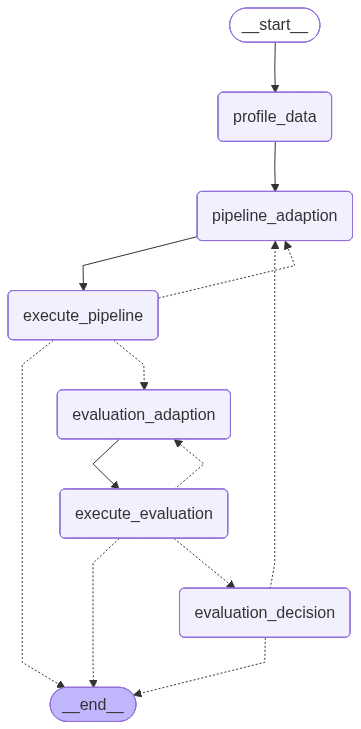

In [14]:
from IPython.display import Image, display

display(Image(agent.graph.get_graph().draw_mermaid_png()))